In [ ]:
# import numpy as np, pymc as pm, aesara.tensor as at
import sys, os
import matplotlib.pyplot as plt
sys.path.append('Utils/')
from ExternalFunctions import nice_string_output, add_text_to_ax
from PlotUtils import setMplParam, getColour, getHistoParam 
setMplParam()
from scipy.optimize import curve_fit, minimize
# taking forever: 1 min 20 sec

In [3]:
# A = [1.0, 2.0, 3.0, 3.3, 3.5]
# B = [1.2, 2.7, 3.7, 3.9, 4.0]
# C = [2.5, 4.0, 4.1, 4.15, 4.2]
# D = [3.5, 4.2, 4.25, 4.28, 4.31]
# E = [4.2, 4.3, 4.35, 4.38, 4.40]
groups = {
    'A': [1.0, 2.0, 3.0, 3.3, 3.5],
    'B': [1.2, 2.7, 3.7, 3.9, 4.0],
    'C': [2.5, 4.0, 4.1, 4.15, 4.2],
    'D': [3.5, 4.2, 4.25, 4.28, 4.31],
    'E': [4.2, 4.3, 4.35, 4.38, 4.40]   
}

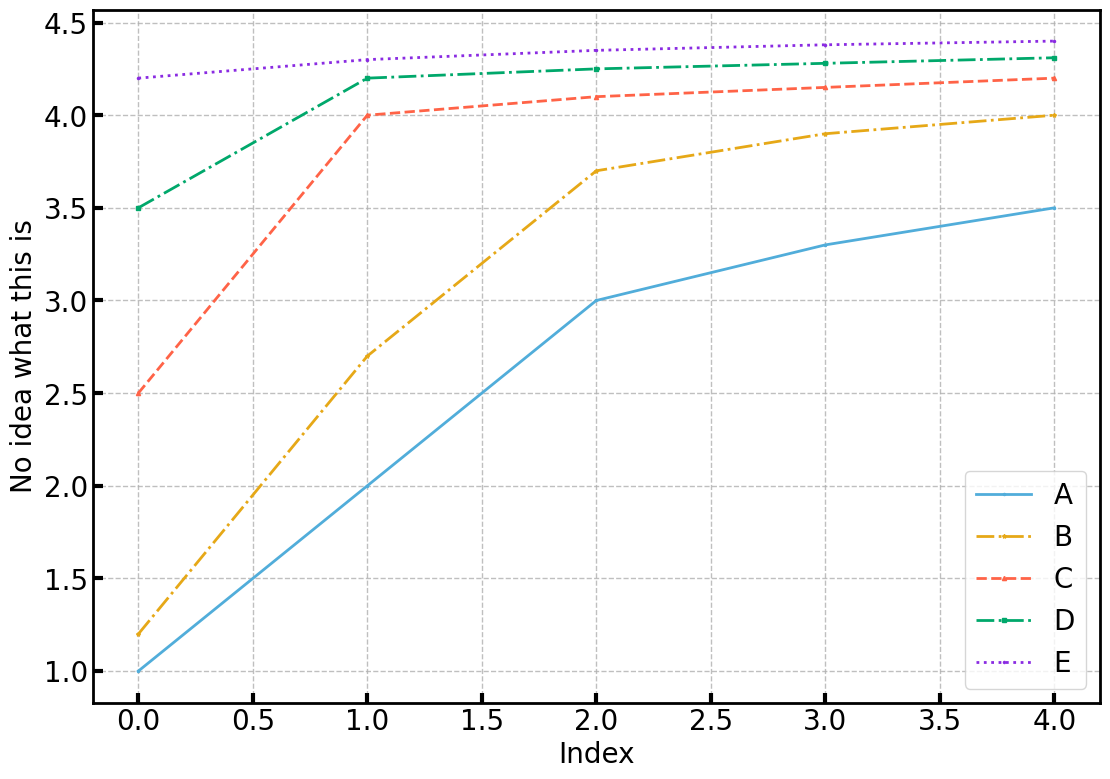

In [4]:
def plot_ABCDE(groups):
    fig, ax = plt.subplots(figsize=(13,9))
    ax.plot(groups['A'], label='A')
    ax.plot(groups['B'], label='B')
    ax.plot(groups['C'], label='C')
    ax.plot(groups['D'], label='D')
    ax.plot(groups['E'], label='E')
    ax.legend(fontsize=20)
    ax.set_xlabel('Index', fontsize=20)
    ax.set_ylabel('No idea what this is', fontsize=20)
    plt.show()      
    
plot_ABCDE(groups)

In [5]:
def exp_curve(x, y0, ymax, k):
    return ymax - (ymax - y0) * np.exp(-k * x)

def mm_curve(x, y0, ymax, K):
    return y0 + ymax * x / (K + x)

def filter_clean_points(y, soft_limit):
    return y < soft_limit

def fit_group(x, y, model, p0):
    popt, _ = curve_fit(model, x, y, p0=p0, maxfev=10000)
    return popt

def shrink_slope(naive, pooled_mean, weight):
    return weight * naive + (1 - weight) * pooled_mean



In [6]:
x = np.arange(1, 6)   # steps 1..5
soft_limit = 4.5      # artificial threshold

# --- Step 4. Fit A–C with exponential ---
slopes = {}
for g in ["A", "B", "C"]:
    y = np.array(groups[g])
    mask = filter_clean_points(y, soft_limit)
    params = fit_group(x[mask], y[mask], exp_curve, p0=[y[0], max(y), 1.0])
    y0, ymax, k = params
    slope = k * (ymax - y0)    # initial slope formula
    slopes[g] = slope

# pooled mean from A–C
pooled_mean = np.mean(list(slopes.values()))

# --- Step 5. Fit D–E naively, then shrink ---
for g in ["D", "E"]:
    y = np.array(groups[g])
    mask = filter_clean_points(y, soft_limit)
    if mask.sum() >= 2:
        params = fit_group(x[mask], y[mask], exp_curve, p0=[y[0], max(y), 1.0])
        y0, ymax, k = params
        naive_slope = k * (ymax - y0)
    else:
        naive_slope = np.nan
    
    # shrink towards pooled mean (weight ~ how many clean points)
    weight = mask.sum() / len(x)   # crude choice
    slope = shrink_slope(naive_slope, pooled_mean, weight)
    slopes[g] = slope

# --- Step 6. Report results ---
print("Initial slope estimates:")
for g, s in slopes.items():
    print(f"{g}: {s:.3f}")

print(f"\nPooled mean slope (A–C): {pooled_mean:.3f}")

Initial slope estimates:
A: 2.474
B: 5.133
C: 37.645
D: 14.426
E: 0.231

Pooled mean slope (A–C): 15.084
